# PHASE 4
# STRUCTURED CLINICAL DESCRIPTION FOR BraTS2021
# Converting Stable Features into a Structured Tumour Description

This notebook converts filtered features from Phase 3 into a structured
description of each tumour (size, tissue composition and morphology) with the provenance of
every value recorded. These structured findings feed the Phase 5 explainer.

**Inputs and outputs:**

* **Input**: the 15 stable features per patient (`05_report_features_final.json`) from Phase 3.
* **Output**: a structured findings object (JSON) per patient, plus a three-panel summary figure
  (segmentation overlay, tissue composition, nested-region volumes).

## Overview

1. **Load** the frozen feature set and group the 15 features into morphology, first-order intensity and volumetric ratios.
2. **Describe** each group using descriptive categories derived from cohort tertiles (the 33rd and  66th percentiles of each measure across the study cohort): tumour size (cm³), composition (necrosis and enhancing fractions) and morphology (margin from sphericity). The categories are cohort-relative descriptive labels, not diagnostic cutoffs, and every value carries a record of its derivation.
3. **Visualise** the results: the predicted segmentation on the key slice, the tissue composition and the nested regions (ET ⊆ TC ⊆ WT) with their volumes.

**Scope: describe, not predict.** This phase reports what the imaging shows with each value traceable to its computation and does not infer tumour grade, type, prognosis, or behaviour - outcomes the BraTS2021 data cannot support.

## 1. Imports, configuration and paths

In [23]:
# Imports
import os
import json
import numpy as np 
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

from scipy import ndimage
import os
import glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Configuration

# BraTS label values (disjoint anatomical tissues in the raw mask)
LABEL_NCR, LABEL_ED, LABEL_ET = 1, 2, 4

# Volume feature names
ET_VOL = "ET_T1CE_original_shape_VoxelVolume"
TC_VOL = "TC_T1CE_original_shape_VoxelVolume"
WT_VOL = "WT_FLAIR_original_shape_VoxelVolume"

# Descriptive bands = tertiles (33rd/66th percentile) of each measure across the
# study cohort (n≈245). Lower/middle/upper third, applied uniformly to all patients.
# Cohort-relative descriptive labels, not diagnostic cutoffs.
NECROSIS_BANDS  = [(0.007, "minimal"), (0.298, "moderate"), (1.01, "extensive")]
ENHANCING_BANDS = [(0.176, "minimal"), (0.339, "moderate"), (1.01, "predominant")]

# Sphericity: LOW = irregular, so labels run in increasing-sphericity order.
SPHERICITY_BANDS = [(0.364, "markedly irregular, infiltrative"),
                    (0.685, "moderately irregular"),
                    (1.01, "relatively regular, well-circumscribed")]

# Feature groups (the 15 stable features from Phase 3)
SHAPE_KEY = "shape"
FIRSTORDER_KEY = "firstorder"
RATIO_KEYS = ["ET_WT_ratio", "ET_TC_ratio", "TC_WT_ratio", "necrosis_fraction"]

print("Config loaded. Bands are descriptive conventions, not diagnostic thresholds.")

Config loaded. Bands are descriptive conventions, not diagnostic thresholds.


In [16]:
# Paths
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

# Phase 3 outputs (the frozen feature set + per-patient features)
feature_dir = os.path.join(project_root, "outputs", "feature_outputs")
masks_dir = os.path.join(project_root, "outputs", "outputs_full_finetuning", "predicted_masks")
data_dir = os.path.join(project_root, "data", "BraTS21", "BraTS2021_Training_Data", "TrainingData")

# Phase 4 outputs
output_dir = os.path.join(project_root, "outputs", "description_outputs")
os.makedirs(output_dir, exist_ok=True)

print("feature_dir exists:", os.path.isdir(feature_dir))
print("masks_dir exists:", os.path.isdir(masks_dir))

feature_dir exists: True
masks_dir exists: True


## 2. Load the feature set

The describe step works on **one patient at a time** - 15 features in, one structured description out - which is exactly how it runs at inference. Here, for validation, the same per-patient logic is applied to every patient in the Phase 3 table at once, so the output can be checked across the cohort.

The frozen list (`05_report_features_final.json`) defines the 15 features, the per-patient values come from the Phase 3 feature table.

In [17]:
# Frozen feature list (the 15 features that survived all Phase 3 filters).
# At inference this same list is applied to a single patient, here it is applied to the
# whole validation table so the description can be checked across the cohort.
with open(os.path.join(project_root, "scripts", "assets", "05_report_features_final.json")) as f:
    frozen = json.load(f)
report_features = frozen["report_features"]
print(f"Frozen report feature set ({len(report_features)} features):")
for feat in report_features:
    print("  -", feat)

# Per-patient feature values. Validation mode: read the cohort table from Phase 3.
# Inference mode: this DataFrame would hold a single row for the current patient.
df = pd.read_csv(os.path.join(feature_dir, "01b_features_gt_with_ratios.csv"))
print(f"\nLoaded features for {len(df)} patient(s).")

Frozen report feature set (15 features):
  - WT_FLAIR_original_shape_VoxelVolume
  - WT_FLAIR_original_shape_Flatness
  - WT_FLAIR_original_shape_Elongation
  - TC_T1CE_original_firstorder_Skewness
  - WT_FLAIR_original_shape_SurfaceVolumeRatio
  - ET_T1CE_original_shape_Flatness
  - ET_T1CE_original_shape_Elongation
  - TC_T1CE_original_shape_SurfaceVolumeRatio
  - WT_FLAIR_original_firstorder_Skewness
  - ET_T1CE_original_shape_Sphericity
  - ET_T1CE_original_shape_SurfaceVolumeRatio
  - TC_WT_ratio
  - ET_WT_ratio
  - necrosis_fraction
  - ET_TC_ratio

Loaded features for 250 patient(s).


In [18]:
# Derive data-grounded category thresholds (tertiles over the cohort)
import numpy as np

def _tertiles(series, name):
    v = series.dropna().values
    t1, t2 = np.percentile(v, [33.33, 66.67])
    print(f"{name}: n={len(v)}  33rd={t1:.3f}  66th={t2:.3f}")
    return round(float(t1), 2), round(float(t2), 2)

# df = your cohort dataframe with one row per patient
nec_t = _tertiles(df["necrosis_fraction"], "necrosis_fraction")
enh_t = _tertiles(df["ET_WT_ratio"], "enhancing_fraction")
sph_t = _tertiles(df["ET_T1CE_original_shape_Sphericity"], "sphericity")

necrosis_fraction: n=248  33rd=0.007  66th=0.298
enhancing_fraction: n=243  33rd=0.176  66th=0.339
sphericity: n=243  33rd=0.364  66th=0.685


## 3. Group the features

The 15 features fall into three groups, handled differently in the report: **shape** (morphology, described qualitatively), **first-order** (intensity statistics, tabulated only) and **volumetric ratios** (composition, described as cited categories).

In [19]:
def group_features(feature_names):
    groups = {"shape": [], "firstorder": [], "ratio": []}
    for f in feature_names:
        if f in RATIO_KEYS:
            groups["ratio"].append(f)
        elif SHAPE_KEY in f:
            groups["shape"].append(f)
        elif FIRSTORDER_KEY in f:
            groups["firstorder"].append(f)
    return groups

feature_groups = group_features(report_features)
for g, fs in feature_groups.items():
    print(f"{g:11} ({len(fs)}): {fs}")

shape       (9): ['WT_FLAIR_original_shape_VoxelVolume', 'WT_FLAIR_original_shape_Flatness', 'WT_FLAIR_original_shape_Elongation', 'WT_FLAIR_original_shape_SurfaceVolumeRatio', 'ET_T1CE_original_shape_Flatness', 'ET_T1CE_original_shape_Elongation', 'TC_T1CE_original_shape_SurfaceVolumeRatio', 'ET_T1CE_original_shape_Sphericity', 'ET_T1CE_original_shape_SurfaceVolumeRatio']
firstorder  (2): ['TC_T1CE_original_firstorder_Skewness', 'WT_FLAIR_original_firstorder_Skewness']
ratio       (4): ['TC_WT_ratio', 'ET_WT_ratio', 'necrosis_fraction', 'ET_TC_ratio']


## 4. Clinical description

Each feature group is translated into a clinically legible form:

- **Size** - reported in cm³ (BraTS is 1 mm isotropic, so voxel volume in mm³ ÷ 1000).
- **Composition** - the disjoint tissues (enhancing, necrotic, edema), which partition the whole tumour and sum to 100%.
- **Morphology** - the shape features, described qualitatively (e.g. margin regularity) rather than as raw numbers, since shape is more clinically legible in words than as decimals.

All categories use soft thresholds from the literature, not diagnostic cutoffs.

In [20]:
def band(value, bands):
    """Return the label of the first band whose upper edge the value falls under."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "indeterminate"
    for edge, label in bands:
        if value < edge:
            return label
    return bands[-1][1]

def disjoint_volumes_cm3(row):
    """Disjoint tissue volumes (cm3) from the nested-region volumes.
    ET = enhancing; NCR = TC - ET; ED = WT - TC. These partition the whole tumour."""
    wt = row.get(WT_VOL, np.nan) / 1000.0
    tc = row.get(TC_VOL, np.nan) / 1000.0
    et = row.get(ET_VOL, np.nan) / 1000.0
    et = 0.0 if np.isnan(et) else et
    ncr = max(tc - et, 0.0) if not np.isnan(tc) else np.nan
    ed  = max(wt - tc, 0.0) if not (np.isnan(wt) or np.isnan(tc)) else np.nan
    return {"enhancing_cm3": round(et, 1), "necrotic_cm3": round(ncr, 1),
            "edema_cm3": round(ed, 1), "whole_tumour_cm3": round(wt, 1),
            "tumour_core_cm3": round(tc, 1)}

def describe_patient(row):
    """Build the structured findings object for one patient. Description only, no prediction."""
    vols = disjoint_volumes_cm3(row)

    # composition (cohort-tertile descriptive bands)
    necrosis = row.get("necrosis_fraction", np.nan)
    et_wt = row.get("ET_WT_ratio", np.nan)
    composition = {
        "necrosis_fraction": None if np.isnan(necrosis) else round(float(necrosis), 3),
        "necrosis_category": band(necrosis, NECROSIS_BANDS),
        "enhancing_fraction_of_wt": None if np.isnan(et_wt) else round(float(et_wt), 3),
        "enhancing_category": band(et_wt, ENHANCING_BANDS),
    }

    # morphology (qualitative: sphericity + surface-volume ratio)
    sph = row.get("ET_T1CE_original_shape_Sphericity", np.nan)
    morphology = {
        "et_sphericity": None if np.isnan(sph) else round(float(sph), 3),
        "margin_descriptor": band(sph, SPHERICITY_BANDS),
    }

    # first-order: tabulated only, not narrated
    firstorder = {f: (None if np.isnan(row.get(f, np.nan)) else round(float(row.get(f)), 3))
                  for f in feature_groups["firstorder"]}

    return {
        "patient_id": row["patient_id"],
        "size_cm3": vols,
        "composition": composition,
        "morphology": morphology,
        "firstorder_table": firstorder,
        "disclaimer": "Descriptive only; not a prediction of grade, molecular status, or outcome.",
    }

# demo on the first patient
example = describe_patient(df.iloc[0])
print(json.dumps(example, indent=2))

{
  "patient_id": "BraTS2021_00002",
  "size_cm3": {
    "enhancing_cm3": 23.7,
    "necrotic_cm3": 11.2,
    "edema_cm3": 155.7,
    "whole_tumour_cm3": 190.6,
    "tumour_core_cm3": 34.9
  },
  "composition": {
    "necrosis_fraction": 0.321,
    "necrosis_category": "extensive",
    "enhancing_fraction_of_wt": 0.124,
    "enhancing_category": "minimal"
  },
  "morphology": {
    "et_sphericity": 0.317,
    "margin_descriptor": "markedly irregular, infiltrative"
  },
  "firstorder_table": {
    "TC_T1CE_original_firstorder_Skewness": 1.303,
    "WT_FLAIR_original_firstorder_Skewness": 0.858
  },
  "disclaimer": "Descriptive only; not a prediction of grade, molecular status, or outcome."
}


## 4. Summary figure

A three-panel figure per patient. **Left:** the predicted segmentation overlaid on the key axial slice (the slice with the largest tumour extent), colour-coded by tissue. **Middle:** the tissue-composition breakdown (enhancing / necrotic / edema) with absolute volumes. **Right:** the nested clinical regions (ET ⊆ TC ⊆ WT) as a volume hierarchy. Together these pair the qualitative (what the tumour looks like) with the quantitative (its size and make-up), as in a structured radiology figure.

BraTS2021_00002:  ET=20.2  NCR=10.6  ED=115.6  TC=30.8  WT=146.4  (cm³)


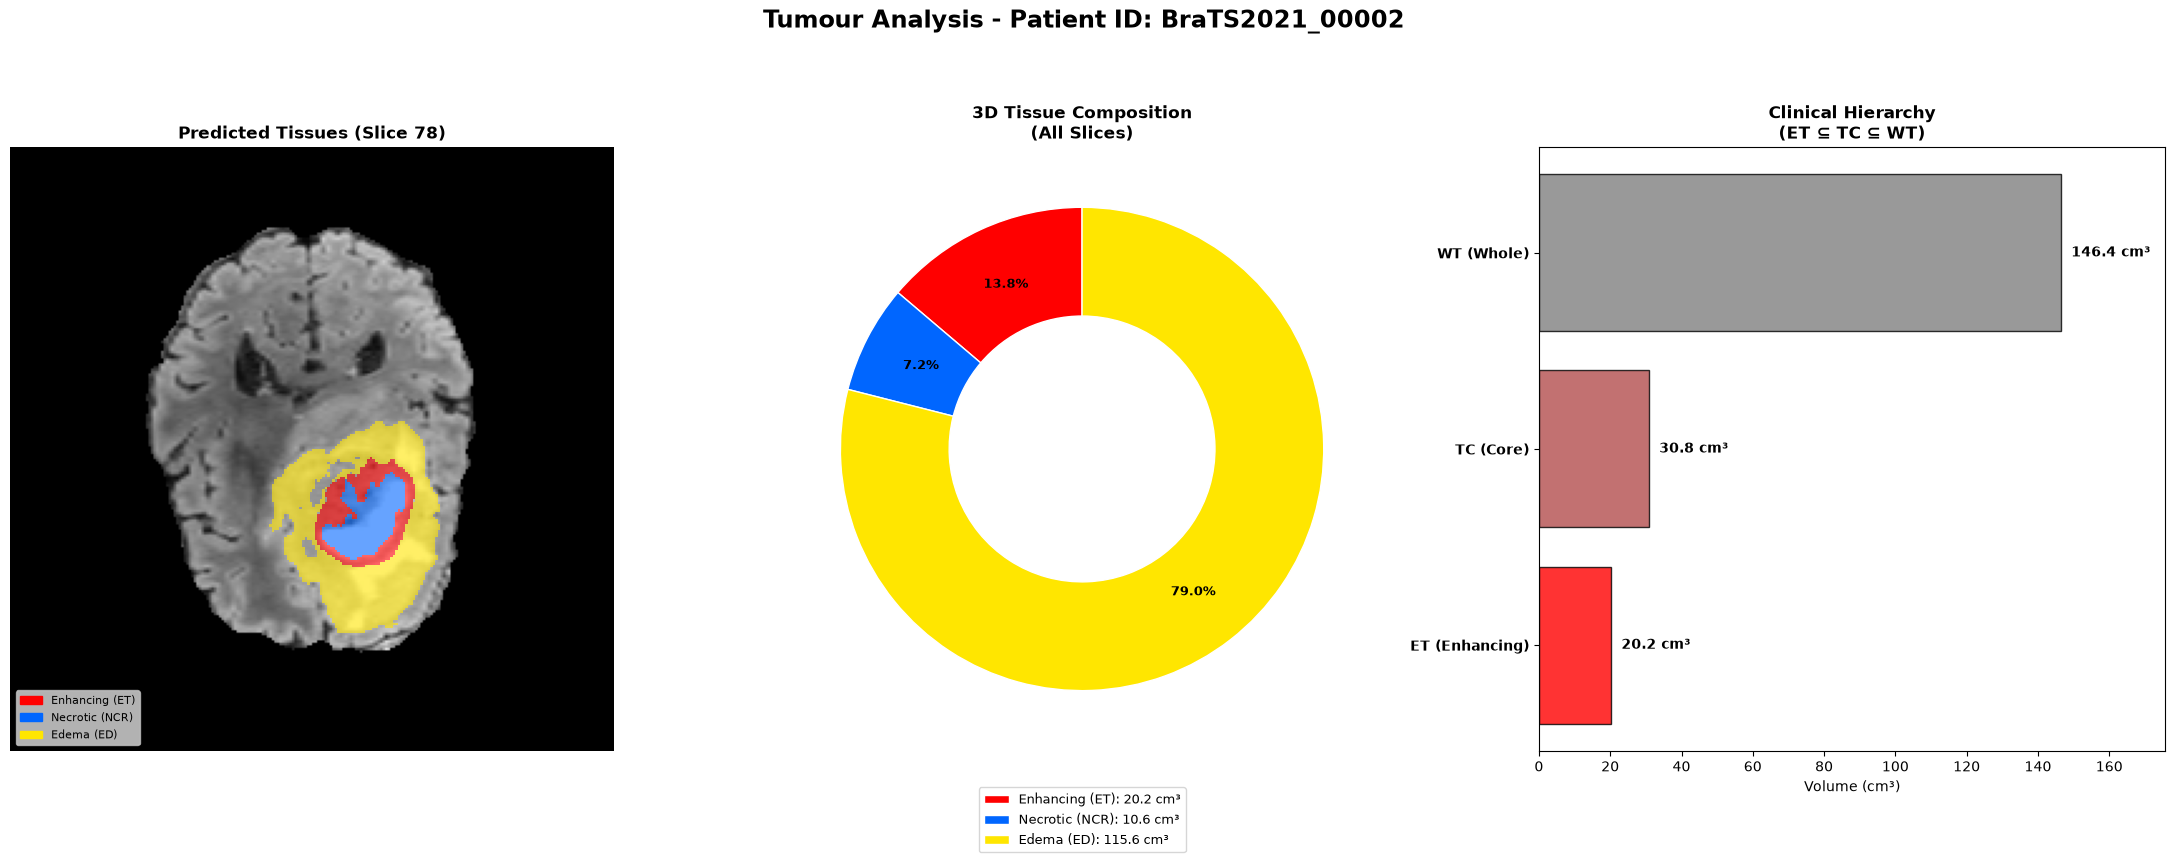

In [24]:
# CONSTANTS AND PLOTTING FUNCTIONS
VOXEL_TO_CM3 = 1.0 / 1000.0   # BraTS voxels are 1mm³; 1000mm³ = 1 cm³
LABEL_NCR, LABEL_ED, LABEL_ET = 1, 2, 4
COLORS = {LABEL_ET: (1.0, 0.0, 0.0),   # Red
          LABEL_NCR: (0.0, 0.4, 1.0),  # Blue
          LABEL_ED: (1.0, 0.9, 0.0)}   # Yellow
NAMES = {LABEL_ET: "Enhancing (ET)", LABEL_NCR: "Necrotic (NCR)", LABEL_ED: "Edema (ED)"}

def _norm01(v):
    v = v.astype(np.float32)
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((v - lo) / (hi - lo), 0, 1) if hi > lo else np.zeros_like(v)

def _key_slice(seg):
    tps = (seg > 0).sum(axis=(0, 1))
    return int(tps.argmax()) if tps.sum() > 0 else seg.shape[2] // 2

def draw_overlay_disjoint(ax, base_vol, seg, z=None, alpha=0.6):
    z = _key_slice(seg) if z is None else z
    b2d = np.rot90(_norm01(base_vol[:, :, z]))
    s2d = np.rot90(seg[:, :, z])
    rgba_mask = np.zeros((*s2d.shape, 4))
    for lab, col in COLORS.items():
        rgba_mask[s2d == lab] = [*col, alpha]
    ax.imshow(b2d, cmap='gray')
    ax.imshow(rgba_mask, interpolation='nearest')
    ax.axis("off")
    ax.set_title(f"Predicted Tissues (Slice {z})", fontsize=12, fontweight='bold')
    patches = [mpatches.Patch(color=COLORS[l], label=NAMES[l]) for l in (LABEL_ET, LABEL_NCR, LABEL_ED)]
    ax.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.7)

def draw_donut_disjoint(ax, et, ncr, ed):
    vals, colors = [], []
    for v, lab in zip((et, ncr, ed), (LABEL_ET, LABEL_NCR, LABEL_ED)):
        if v > 0:
            vals.append(v); colors.append(COLORS[lab])
    if sum(vals) > 0:
        wedges, _, autotexts = ax.pie(vals, colors=colors, autopct='%1.1f%%',
                                      startangle=90, pctdistance=0.75,
                                      wedgeprops=dict(width=0.45, edgecolor='w'))
        plt.setp(autotexts, size=9, weight="bold")
    legend_labels = [f"{NAMES[LABEL_ET]}: {et:.1f} cm³",
                     f"{NAMES[LABEL_NCR]}: {ncr:.1f} cm³",
                     f"{NAMES[LABEL_ED]}: {ed:.1f} cm³"]
    ax.legend(legend_labels, loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=9)
    ax.set_title("3D Tissue Composition\n(All Slices)", fontsize=12, fontweight='bold')

def draw_nested_bars(ax, et_v, tc_v, wt_v):
    vals = [wt_v, tc_v, et_v]
    labels = ["WT (Whole)", "TC (Core)", "ET (Enhancing)"]
    colors = [(0.5, 0.5, 0.5), (0.7, 0.3, 0.3), (1.0, 0.0, 0.0)]
    ypos = np.arange(3)[::-1]
    ax.barh(ypos, vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontweight='bold')
    ax.set_title("Clinical Hierarchy\n(ET ⊆ TC ⊆ WT)", fontsize=12, fontweight='bold')
    span = max(vals) if max(vals) > 0 else 1.0
    for i, v in enumerate(vals):
        ax.text(v + span * 0.02, ypos[i], f'{v:.1f} cm³', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, span * 1.2)
    ax.set_xlabel("Volume (cm³)")

def figure_unified_summary(base_vol, seg, et_v, ncr_v, ed_v, pid=""):
    tc_v, wt_v = et_v + ncr_v, et_v + ncr_v + ed_v
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))
    draw_overlay_disjoint(ax1, base_vol, seg)
    draw_donut_disjoint(ax2, et_v, ncr_v, ed_v)
    draw_nested_bars(ax3, et_v, tc_v, wt_v)
    fig.suptitle(f"Swin UNETR Segmentation Report - Patient ID: {pid}",
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def _clean_one(binary):
    """Largest connected component + fill holes (Phase 3 post-processing)."""
    if binary.sum() == 0:
        return binary
    labeled, n = ndimage.label(binary)
    if n > 1:
        sizes = np.bincount(labeled.ravel()); sizes[0] = 0
        binary = (labeled == sizes.argmax()).astype(np.uint8)
    return ndimage.binary_fill_holes(binary).astype(np.uint8)

def clean_label_map(label_map):
    """Clean each disjoint region (NCR, ED, ET) and reassemble, so the figure's
    volumes match the post-processed pipeline."""
    label_map = label_map.astype(np.uint8)
    cleaned = np.zeros_like(label_map)
    for lab in (LABEL_NCR, LABEL_ED, LABEL_ET):
        binary = _clean_one((label_map == lab).astype(np.uint8))
        cleaned[binary == 1] = lab
    return cleaned

def figure_unified_summary(base_vol, seg, et_cm3, ncr_cm3, ed_cm3, pid=""):
    """One row: segmentation overlay | composition donut | nested-region bars.
    All three use the same disjoint colour language (red/blue/yellow)."""
    tc_cm3 = et_cm3 + ncr_cm3
    wt_cm3 = tc_cm3 + ed_cm3
    fig, (ax_img, ax_pie, ax_bar) = plt.subplots(1, 3, figsize=(22, 8))
    draw_overlay_disjoint(ax_img, base_vol, seg)
    draw_donut_disjoint(ax_pie, et_cm3, ncr_cm3, ed_cm3)
    draw_nested_bars(ax_bar, et_cm3, tc_cm3, wt_cm3)
    fig.suptitle(f"Tumour Analysis - Patient ID: {pid}", fontsize=17, fontweight="bold", y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

# SINGLE PATIENT
PID = "BraTS2021_00002"   # Change

mask_path  = os.path.join(masks_dir, f"pred_{PID}.nii.gz")
flair_path = os.path.join(data_dir, PID, f"{PID}_flair.nii.gz")

assert os.path.exists(mask_path),  f"Mask not found: {mask_path}"
assert os.path.exists(flair_path), f"FLAIR not found: {flair_path}"

flair_vol = nib.load(flair_path).get_fdata()
seg_map = nib.load(mask_path).get_fdata()
seg_map = clean_label_map(seg_map)

et_v  = np.sum(seg_map == LABEL_ET)  * VOXEL_TO_CM3
ncr_v = np.sum(seg_map == LABEL_NCR) * VOXEL_TO_CM3
ed_v  = np.sum(seg_map == LABEL_ED)  * VOXEL_TO_CM3
print(f"{PID}:  ET={et_v:.1f}  NCR={ncr_v:.1f}  ED={ed_v:.1f}  "
      f"TC={et_v+ncr_v:.1f}  WT={et_v+ncr_v+ed_v:.1f}  (cm³)")

fig = figure_unified_summary(flair_vol, seg_map, et_v, ncr_v, ed_v, pid=PID)
fig.savefig(os.path.join(output_dir, f"{PID}_report.png"), dpi=150, bbox_inches='tight')
plt.show()

## 5. Generate structured findings for all patients

Build and save the structured findings object for every patient (the input the Phase 5 language model consumes), and the summary figure for each. Phase 5 turns the structured findings into prose; it never sees raw feature values, only the categorised description produced here.

In [25]:
import glob

# ALL PATIENTS
mask_files = sorted(glob.glob(os.path.join(masks_dir, "*.nii.gz")))
print(f"Processing {len(mask_files)} patients...\n")

made, missing = 0, 0
for m_path in mask_files:
    # strip 'pred_' prefix and extension to get the real patient id
    pid = os.path.basename(m_path).replace('.nii.gz', '').replace('.nii', '')
    if pid.startswith('pred_'):
        pid = pid[len('pred_'):]

    flair_path = os.path.join(data_dir, pid, f"{pid}_flair.nii.gz")
    if not os.path.exists(flair_path):
        print(f"Missing FLAIR for {pid}")
        missing += 1
        continue

    flair_vol = nib.load(flair_path).get_fdata()
    seg_map   = nib.load(m_path).get_fdata()

    et_v  = np.sum(seg_map == LABEL_ET)  * VOXEL_TO_CM3
    ncr_v = np.sum(seg_map == LABEL_NCR) * VOXEL_TO_CM3
    ed_v  = np.sum(seg_map == LABEL_ED)  * VOXEL_TO_CM3

    fig = figure_unified_summary(flair_vol, seg_map, et_v, ncr_v, ed_v, pid=pid)
    fig.savefig(os.path.join(output_dir, f"{pid}_report.png"), dpi=150, bbox_inches='tight')
    plt.close(fig)  

    made += 1
    if made % 25 == 0:
        print(f"  ... {made} done")

print(f"\n{made} reports saved - description_outputs. ({missing} missing FLAIR.)")

Processing 250 patients...

  ... 25 done
  ... 50 done
  ... 75 done
  ... 100 done
  ... 125 done
  ... 150 done
  ... 175 done
  ... 200 done
  ... 225 done
  ... 250 done

250 reports saved - description_outputs. (0 missing FLAIR.)


## End of notebook

All experiments completed. Results are saved and can be used for further analysis or reporting.